# 機械学習のための数学 — インタラクティブノートブック

NumPy を使って線形代数・確率・最適化の概念を実装します。  
依存: `pip install numpy matplotlib`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42) 
np.set_printoptions(precision=4, suppress=True)
print("NumPy version:", np.__version__)

NumPy version: 2.2.6


## 1. 線形代数

In [3]:
# ベクトル演算
v = np.array([1, 2, 3], dtype=float)
u = np.array([4, 5, 6], dtype=float)

print(f"ベクトル v = {v}")
print(f"L2 ノルム ||v|| = {np.linalg.norm(v):.4f}")
print(f"内積 v·u = {np.dot(v, u):.4f}")
print(f"コサイン類似度 = {np.dot(v, u) / (np.linalg.norm(v) * np.linalg.norm(u)):.4f}")

ベクトル v = [1. 2. 3.]
L2 ノルム ||v|| = 3.7417
内積 v·u = 32.0000
コサイン類似度 = 0.9746


In [4]:
# 行列演算
A = np.array([[2., 1., 0.],
              [1., 3., 1.],
              [0., 1., 2.]])

print("行列 A:")
print(A)
print(f"\n行列式: {np.linalg.det(A):.4f}")

A_inv = np.linalg.inv(A)
print("\n逆行列 A⁻¹:")
print(A_inv)

print("\nA @ A⁻¹ ≈ 単位行列:", np.allclose(A @ A_inv, np.eye(3)))

行列 A:
[[2. 1. 0.]
 [1. 3. 1.]
 [0. 1. 2.]]

行列式: 8.0000

逆行列 A⁻¹:
[[ 0.625 -0.25   0.125]
 [-0.25   0.5   -0.25 ]
 [ 0.125 -0.25   0.625]]

A @ A⁻¹ ≈ 単位行列: True


In [5]:
# 固有値・固有ベクトル
eigenvalues, eigenvectors = np.linalg.eig(A)
print("固有値:", eigenvalues)
print("\n固有ベクトル（列ごと）:")
print(eigenvectors)

# 検証: Av = λv
print("\n検証 (A @ v ≈ λ * v):")
for i in range(len(eigenvalues)):
    lam = eigenvalues[i]
    vec = eigenvectors[:, i]
    ok = np.allclose(A @ vec, lam * vec)
    print(f"  λ = {lam:.4f}: {ok}")

固有値: [4. 2. 1.]

固有ベクトル（列ごと）:
[[-0.4082  0.7071  0.5774]
 [-0.8165 -0.     -0.5774]
 [-0.4082 -0.7071  0.5774]]

検証 (A @ v ≈ λ * v):
  λ = 4.0000: True
  λ = 2.0000: True
  λ = 1.0000: True


## 2. 確率・統計

In [6]:
data = np.array([2, 4, 4, 4, 5, 5, 7, 9], dtype=float)
print(f"データ: {data}")
print(f"平均 (E[X])  : {np.mean(data):.4f}")
print(f"分散 (Var[X]): {np.var(data):.4f}")
print(f"標準偏差 (σ) : {np.std(data):.4f}")
print(f"中央値       : {np.median(data):.4f}")

データ: [2. 4. 4. 4. 5. 5. 7. 9.]
平均 (E[X])  : 5.0000
分散 (Var[X]): 4.0000
標準偏差 (σ) : 2.0000
中央値       : 4.5000


/tmp/ipykernel_16941/2015439280.py:11: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16941/2015439280.py:11: UserWarning: Glyph 35215 (\N{CJK UNIFIED IDEOGRAPH-898F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16941/2015439280.py:11: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16941/2015439280.py:11: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16941/2015439280.py:11: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16941/2015439280.py:11: UserWarning: Glyph 27096 (\N{CJK UNIFIED IDEOGRAPH-69D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/abemc/project_root/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:1

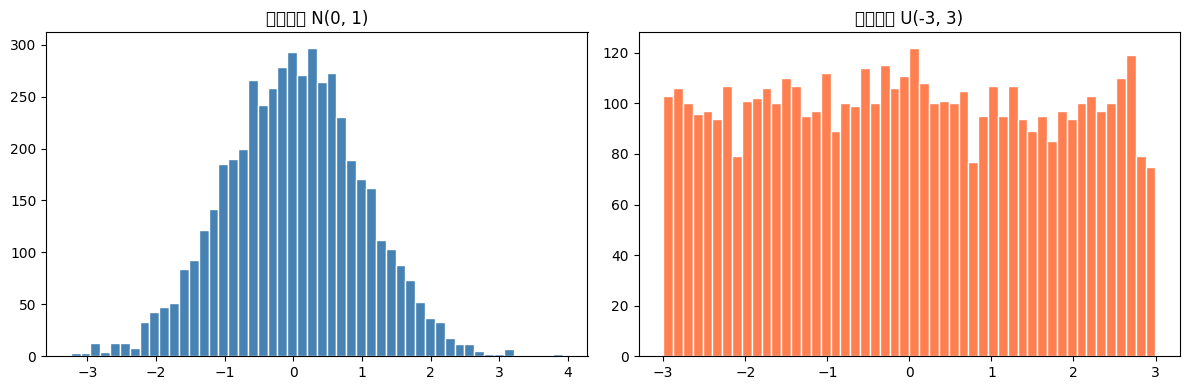

±1σ 内: 68.7%  (理論値: 68.3%)
±2σ 内: 95.4%  (理論値: 95.4%)


In [7]:
# 主要な確率分布のサンプリング
n = 5000
normal_samples  = np.random.normal(0, 1, n)
uniform_samples = np.random.uniform(-3, 3, n)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(normal_samples, bins=50, color="steelblue", edgecolor="w")
axes[0].set_title("正規分布 N(0, 1)")
axes[1].hist(uniform_samples, bins=50, color="coral", edgecolor="w")
axes[1].set_title("一様分布 U(-3, 3)")
plt.tight_layout()
plt.show()

# 68–95–99.7 則の確認
within_1std = np.mean(np.abs(normal_samples) <= 1) * 100
within_2std = np.mean(np.abs(normal_samples) <= 2) * 100
print(f"±1σ 内: {within_1std:.1f}%  (理論値: 68.3%)")
print(f"±2σ 内: {within_2std:.1f}%  (理論値: 95.4%)")

## 3. 勾配降下法

In [8]:
def numerical_gradient(f, v, h=1e-5):
    """数値微分で勾配を計算する（中心差分）。"""
    grad = np.zeros_like(v, dtype=float)
    for i in range(len(v)):
        vp = v.copy(); vp[i] += h
        vm = v.copy(); vm[i] -= h
        grad[i] = (f(vp) - f(vm)) / (2 * h)
    return grad

# f(x, y) = (x-3)^2 + 2(y+1)^2  最小点: (3, -1)
f       = lambda v: (v[0] - 3)**2 + 2*(v[1] + 1)**2
grad_f  = lambda v: np.array([2*(v[0]-3), 4*(v[1]+1)])

v0 = np.array([0.0, 0.0])
print("数値勾配:", numerical_gradient(f, v0))
print("解析勾配:", grad_f(v0))
print("一致:", np.allclose(numerical_gradient(f, v0), grad_f(v0)))

数値勾配: [-6.  4.]
解析勾配: [-6.  4.]
一致: True


最小点: x = 3.000000, y = -1.000000  (目標: x=3, y=-1)


/tmp/ipykernel_16941/2706539106.py:21: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16941/2706539106.py:21: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16941/2706539106.py:21: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16941/2706539106.py:21: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16941/2706539106.py:21: UserWarning: Glyph 25613 (\N{CJK UNIFIED IDEOGRAPH-640D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16941/2706539106.py:21: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16941/2706539106.py:21: UserWarning: Glyph 21246 (\N{CJK UNIFIED IDEOGRAPH-52FE}) missing from font

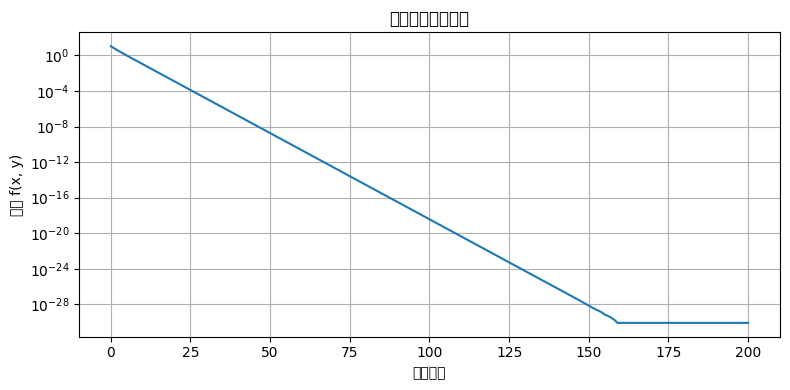

In [9]:
def gradient_descent(f, grad_fn, x_init, lr=0.1, n_iter=200):
    x = x_init.copy()
    history = [x.copy()]
    losses  = [f(x)]
    for _ in range(n_iter):
        x -= lr * grad_fn(x)
        history.append(x.copy())
        losses.append(f(x))
    return x, history, losses

x_min, history, losses = gradient_descent(f, grad_f, np.array([0.0, 0.0]))
print(f"最小点: x = {x_min[0]:.6f}, y = {x_min[1]:.6f}  (目標: x=3, y=-1)")

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("ステップ")
plt.ylabel("損失 f(x, y)")
plt.title("勾配降下法の収束")
plt.yscale("log")
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. PCA（主成分分析）の手実装

第1主成分の寄与率: 98.8%
第2主成分の寄与率: 1.2%


/tmp/ipykernel_16941/1811717099.py:35: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16941/1811717099.py:35: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16941/1811717099.py:35: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16941/1811717099.py:35: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16941/1811717099.py:35: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16941/1811717099.py:35: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16941/1811717099.py:35: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing fro

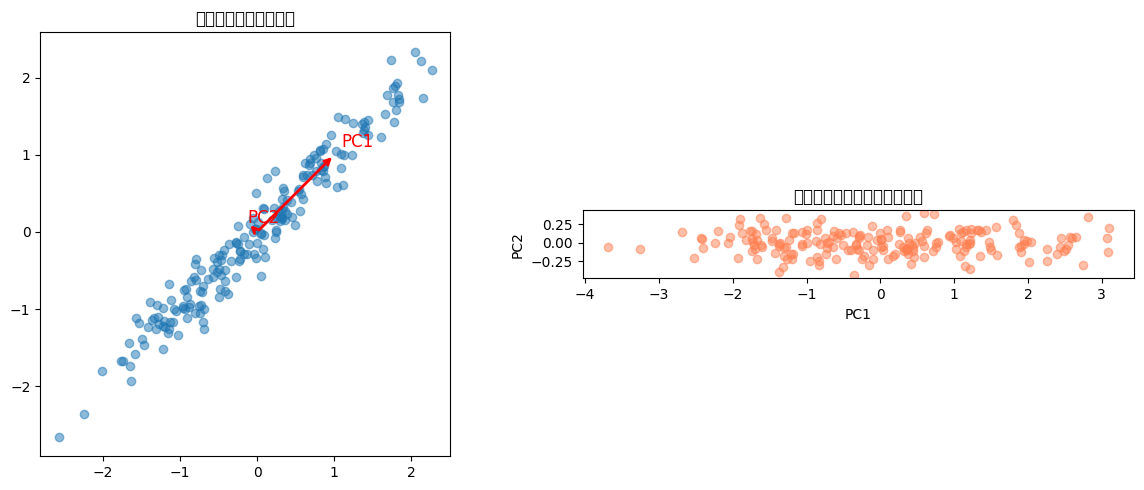

In [10]:
np.random.seed(0)
x_data = np.random.randn(200)
y_data = 0.8 * x_data + 0.2 * np.random.randn(200)
X = np.column_stack([x_data, y_data])

# 標準化
X_std = (X - X.mean(axis=0)) / X.std(axis=0)

# 共分散行列 → 固有値分解
cov = np.cov(X_std.T)
eigvals, eigvecs = np.linalg.eig(cov)
idx     = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print(f"第1主成分の寄与率: {eigvals[0]/eigvals.sum()*100:.1f}%")
print(f"第2主成分の寄与率: {eigvals[1]/eigvals.sum()*100:.1f}%")

X_pca = X_std @ eigvecs

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_std[:, 0], X_std[:, 1], alpha=0.5)
for i, (ev, label) in enumerate(zip(eigvecs.T, ["PC1", "PC2"])):
    axes[0].annotate("", xy=ev * eigvals[i]**0.5, xytext=(0, 0),
                     arrowprops=dict(arrowstyle="->", color="red", lw=2))
    axes[0].text(*(ev * eigvals[i]**0.5 * 1.1), label, color="red", fontsize=12)
axes[0].set_title("元のデータと主成分軸")
axes[0].set_aspect("equal")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, color="coral")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("主成分空間に射影したデータ")
axes[1].set_aspect("equal")
plt.tight_layout()
plt.show()